# Epidemiological Intelligence — Modelagem Estatística
## Bronquite Crônica

## Objetivo

Modelar a relação entre variáveis climáticas e casos de **bronquite crônica**, seguindo a metodologia de `02_modeling.ipynb` e implementada em `data_science/src/modeling_utils.py`: OLS (baseline), Poisson (baseline de contagem) e Binomial Negativa (modelo principal, dada a sobredispersão observada).

A modelagem considera sazonalidade, diferenças estruturais entre municípios e variáveis climáticas selecionadas por testes individuais e de defasagem (lags). Validação sempre temporal (treino `< 2024-01-01`, teste `2024-01` a `2025-12`), nunca aleatória.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import modeling_utils as mu

## 1. Carregamento dos dados

Dados de `epidemiology_climate_monthly` (BigQuery), lidos do cache local via `load_raw_data()` (sem consulta ao BigQuery).

In [2]:
df = mu.load_raw_data()

print("Shape:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

Shape: (21384, 19)

Colunas:
['municipality', 'year', 'month', 'municipality_code', 'reference_date', 'cases', 'source_file', 'ingestion_timestamp', 'disease', 'precipitation_sum_mm', 'precipitation_avg_observation_mm', 'precipitation_max_observation_mm', 'temperature_avg_c', 'dew_point_avg_c', 'relative_humidity_avg_pct', 'atmospheric_pressure_avg_mb', 'wind_speed_avg_ms', 'wind_gust_max_ms', 'station_count']


In [3]:
# `load_raw_data` já converte a coluna para datetime; confirmamos aqui.
print(df["reference_date"].dtype)
df["reference_date"].head()

datetime64[ms]


0   2015-01-01
1   2015-01-01
2   2015-01-01
3   2015-01-01
4   2015-01-01
Name: reference_date, dtype: datetime64[ms]

## 2. Doença designada

Este notebook modela especificamente **BRONQUITE CRÔNICA** (`disease_key = "bronquite_cronica"`).

In [4]:
DISEASE = mu.DISEASES["bronquite_cronica"]
print("Doença modelada:", DISEASE)

Doença modelada: BRONQUITE CRÔNICA


## 3. Lags climáticos

Lags construídos via `build_climate_monthly_lags` (cache em `climate_monthly_lags.parquet`), com validação interna de conflitos, duplicatas e quebras na série mensal por município. Reproduzido abaixo de forma auditável.

In [5]:
climate_monthly = mu.build_climate_monthly_lags(df)

print("Shape da tabela climática mensal:", climate_monthly.shape)
climate_monthly.head()

Shape da tabela climática mensal: (3564, 38)


,municipality,reference_date,temperature_avg_c,dew_point_avg_c,relative_humidity_avg_pct,atmospheric_pressure_avg_mb,wind_speed_avg_ms,wind_gust_max_ms,precipitation_sum_mm,precipitation_avg_observation_mm,...,wind_gust_max_ms_lag3,precipitation_sum_mm_lag1,precipitation_sum_mm_lag2,precipitation_sum_mm_lag3,precipitation_avg_observation_mm_lag1,precipitation_avg_observation_mm_lag2,precipitation_avg_observation_mm_lag3,precipitation_max_observation_mm_lag1,precipitation_max_observation_mm_lag2,precipitation_max_observation_mm_lag3
0,BAGE,2015-01-01,23.013190,18.240915,76.601615,986.807268,3.125303,21.9,207.4,0.279139,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAGE,2015-02-01,22.666964,18.032440,77.096726,986.839435,3.023065,21.9,87.8,0.130655,...,NaN,207.4,NaN,NaN,0.279139,NaN,NaN,27.0,NaN,NaN
2,BAGE,2015-03-01,21.791667,16.303495,73.721774,988.435484,2.903495,14.0,32.4,0.043548,...,NaN,87.8,207.4,NaN,0.130655,0.279139,NaN,23.0,27.0,NaN
3,BAGE,2015-04-01,18.948889,12.562361,69.625000,990.361389,2.857639,16.3,21.2,0.029444,...,21.9,32.4,87.8,207.4,0.043548,0.130655,0.279139,8.0,23.0,27.0
4,BAGE,2015-05-01,15.845652,11.959103,79.375000,991.782473,2.976223,19.4,126.2,0.171467,...,21.9,21.2,32.4,87.8,0.029444,0.043548,0.130655,9.8,8.0,23.0


In [6]:
duplicates = int(
    climate_monthly.duplicated(subset=["municipality", "reference_date"]).sum()
)
print("Duplicatas município/mês:", duplicates)

check_dates = climate_monthly[["municipality", "reference_date"]].copy()
check_dates["previous_date"] = (
    check_dates.groupby("municipality")["reference_date"].shift(1)
)
check_dates["month_difference"] = (
    (check_dates["reference_date"].dt.year * 12 + check_dates["reference_date"].dt.month)
    - (check_dates["previous_date"].dt.year * 12 + check_dates["previous_date"].dt.month)
)

date_gaps = check_dates[
    check_dates["previous_date"].notna()
    & (check_dates["month_difference"] != 1)
]
print("Quebras na sequência mensal:", len(date_gaps))

check_climate = (
    climate_monthly[climate_monthly["municipality"] == "PORTO ALEGRE"]
    [
        [
            "reference_date",
            "wind_gust_max_ms",
            "wind_gust_max_ms_lag1",
            "wind_gust_max_ms_lag2",
            "wind_gust_max_ms_lag3"
        ]
    ]
    .sort_values("reference_date")
)

display(check_climate.head(12))

Duplicatas município/mês: 0
Quebras na sequência mensal: 0


,reference_date,wind_gust_max_ms,wind_gust_max_ms_lag1,wind_gust_max_ms_lag2,wind_gust_max_ms_lag3
1716,2015-01-01,20.5,NaN,NaN,NaN
1717,2015-02-01,13.3,20.5,NaN,NaN
1718,2015-03-01,10.8,13.3,20.5,NaN
1719,2015-04-01,13.2,10.8,13.3,20.5
1720,2015-05-01,14.5,13.2,10.8,13.3
1721,2015-06-01,12.5,14.5,13.2,10.8
1722,2015-07-01,15.6,12.5,14.5,13.2
1723,2015-08-01,18.2,15.6,12.5,14.5
1724,2015-09-01,14.7,18.2,15.6,12.5
1725,2015-10-01,21.8,14.7,18.2,15.6


In [7]:
df = mu.merge_climate_lags(df, climate_monthly)

check_lags = (
    df[
        (df["municipality"] == "PORTO ALEGRE")
        & (df["disease"] == DISEASE)
    ]
    [
        [
            "reference_date",
            "cases",
            "wind_gust_max_ms",
            "wind_gust_max_ms_lag1",
            "wind_gust_max_ms_lag2",
            "precipitation_sum_mm",
            "precipitation_sum_mm_lag1",
            "precipitation_sum_mm_lag2"
        ]
    ]
    .sort_values("reference_date")
)

display(check_lags.head(12))

,reference_date,cases,wind_gust_max_ms,wind_gust_max_ms_lag1,wind_gust_max_ms_lag2,precipitation_sum_mm,precipitation_sum_mm_lag1,precipitation_sum_mm_lag2
80,2015-01-01,99,20.5,NaN,NaN,159.8,NaN,NaN
242,2015-02-01,110,13.3,20.5,NaN,99.4,159.8,NaN
404,2015-03-01,119,10.8,13.3,20.5,54.0,99.4,159.8
566,2015-04-01,116,13.2,10.8,13.3,76.0,54.0,99.4
728,2015-05-01,158,14.5,13.2,10.8,142.4,76.0,54.0
890,2015-06-01,182,12.5,14.5,13.2,172.4,142.4,76.0
1052,2015-07-01,233,15.6,12.5,14.5,313.4,172.4,142.4
1214,2015-08-01,151,18.2,15.6,12.5,111.6,313.4,172.4
1376,2015-09-01,124,14.7,18.2,15.6,186.6,111.6,313.4
1538,2015-10-01,142,21.8,14.7,18.2,312.6,186.6,111.6


## 4. Split temporal

O corte é fixo em `2024-01-01`: treino contém tudo antes dessa data, teste (backtest) contém `2024-01` a `2025-12`. Nunca é usado split aleatório.

In [8]:
train_df, test_df = mu.temporal_split(df)

print("Treino:", train_df["reference_date"].min(), "->", train_df["reference_date"].max())
print("Teste:", test_df["reference_date"].min(), "->", test_df["reference_date"].max())

print("\nTreino shape:", train_df.shape)
print("Teste shape:", test_df.shape)

Treino: 2015-01-01 00:00:00 -> 2023-12-01 00:00:00
Teste: 2024-01-01 00:00:00 -> 2025-12-01 00:00:00

Treino shape: (17496, 46)
Teste shape: (3888, 46)


## 5. Filtragem da doença

`prepare_disease_frame` filtra a doença, remove (não preenche) linhas com valores ausentes e ajusta tipos para `patsy`/`statsmodels`. Nesta etapa usamos apenas `cases`, `municipality` e `month` (ainda sem features climáticas).

In [9]:
train_disease0 = mu.prepare_disease_frame(train_df, DISEASE)
test_disease0 = mu.prepare_disease_frame(test_df, DISEASE)

print("Treino (doença):", train_disease0.shape)
print("Teste (doença):", test_disease0.shape)

train_disease0["cases"].describe()

Treino (doença): (2916, 46)
Teste (doença): (648, 46)


count    2916.000000
mean       11.047668
std        26.211505
min         0.000000
25%         2.000000
50%         5.000000
75%         9.000000
max       233.000000
Name: cases, dtype: float64

## 6. Baseline simples e justificativa metodológica (OLS → Poisson → Binomial Negativa)

Reproduzimos a mesma sequência do notebook de referência (baseline pela média, OLS, Poisson e Binomial Negativa simples, usando apenas `temperature_avg_c`) para justificar a escolha da Binomial Negativa dada a sobredispersão observada.

In [10]:
baseline_prediction = train_disease0["cases"].mean()

test_baseline = test_disease0.copy()
test_baseline["baseline_pred"] = baseline_prediction

baseline_mae = mean_absolute_error(test_baseline["cases"], test_baseline["baseline_pred"])
baseline_rmse = np.sqrt(mean_squared_error(test_baseline["cases"], test_baseline["baseline_pred"]))

print("Média histórica de casos (treino):", baseline_prediction)
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Média histórica de casos (treino): 11.04766803840878
Baseline MAE: 11.636648165083235
Baseline RMSE: 28.965969299354008


In [11]:
ols_simple = smf.ols(
    formula="cases ~ temperature_avg_c",
    data=train_disease0
).fit()

print(ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  cases   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.321
Date:                Wed, 26 Aug 2026   Prob (F-statistic):              0.250
Time:                        19:16:04   Log-Likelihood:                -13356.
No. Observations:                2844   AIC:                         2.672e+04
Df Residuals:                    2842   BIC:                         2.673e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            13.8867      2.39

In [12]:
test_ols = test_disease0.copy()
test_ols["ols_pred"] = ols_simple.predict(test_ols)

ols_eval = test_ols[test_ols["cases"].notna() & test_ols["ols_pred"].notna()]

ols_mae = mean_absolute_error(ols_eval["cases"], ols_eval["ols_pred"])
ols_rmse = np.sqrt(mean_squared_error(ols_eval["cases"], ols_eval["ols_pred"]))

print("OLS MAE:", ols_mae)
print("OLS RMSE:", ols_rmse)
print("Previsões negativas:", (ols_eval["ols_pred"] < 0).sum())

OLS MAE: 11.947870492581709
OLS RMSE: 30.203501855299628
Previsões negativas: 0


**OLS com temperatura.** Coeficiente de `temperature_avg_c` ≈ -0,14, p ≈ 0,25 (sem significância a 5%). R² ≈ 0,0005; MAE/RMSE no teste (≈11,95/≈30,20) piores que o baseline (≈11,64/≈28,97). Temperatura isolada tem pouco poder explicativo, sem controle por município ou sazonalidade.

In [13]:
poisson_simple = smf.glm(
    formula="cases ~ temperature_avg_c",
    data=train_disease0,
    family=sm.families.Poisson()
).fit()

test_poisson = test_disease0.copy()
test_poisson["poisson_pred"] = poisson_simple.predict(test_poisson)
poisson_eval = test_poisson[test_poisson["cases"].notna() & test_poisson["poisson_pred"].notna()]

poisson_mae = mean_absolute_error(poisson_eval["cases"], poisson_eval["poisson_pred"])
poisson_rmse = np.sqrt(mean_squared_error(poisson_eval["cases"], poisson_eval["poisson_pred"]))

dispersion = poisson_simple.pearson_chi2 / poisson_simple.df_resid

print("Poisson MAE:", poisson_mae)
print("Poisson RMSE:", poisson_rmse)
print("Dispersão (Pearson chi2 / df_resid):", dispersion)

Poisson MAE: 11.949552192701585
Poisson RMSE: 30.203865487028292
Dispersão (Pearson chi2 / df_resid): 62.74580165013125


**Regressão de Poisson.** MAE/RMSE quase idênticos ao OLS. Razão qui-quadrado de Pearson / graus de liberdade ≈ 62,7 (muito acima de 1) — confirma forte sobredispersão, justificando a Binomial Negativa para o restante da análise.

In [14]:
nb_simple = smf.negativebinomial(
    formula="cases ~ temperature_avg_c",
    data=train_disease0
).fit(disp=False)

test_nb = test_disease0.copy()
test_nb["nb_pred"] = nb_simple.predict(test_nb)
nb_eval = test_nb[test_nb["cases"].notna() & test_nb["nb_pred"].notna()]

nb_mae = mean_absolute_error(nb_eval["cases"], nb_eval["nb_pred"])
nb_rmse = np.sqrt(mean_squared_error(nb_eval["cases"], nb_eval["nb_pred"]))

print("Coef. temperatura:", nb_simple.params.get("temperature_avg_c"))
print("p-valor temperatura:", nb_simple.pvalues.get("temperature_avg_c"))
print("Alpha:", nb_simple.params.get("alpha"))
print("NB simples MAE:", nb_mae)
print("NB simples RMSE:", nb_rmse)

Coef. temperatura:

 -0.013168105110624748
p-valor temperatura: 0.02981050602887188
Alpha: 1.530565721084835
NB simples MAE: 11.94865572597882
NB simples RMSE: 30.20368311509728


**Binomial Negativa simples.** O coeficiente de temperatura passa a ser significativo (p ≈ 0,03), mas MAE/RMSE seguem próximos do baseline — um único regressor climático, sem município nem sazonalidade, ainda não basta. Motiva o modelo-base com efeitos fixos a seguir.

## 7. Modelo-base Binomial Negativa (município + mês)

Este é o **modelo de referência da doença**: Binomial Negativa com `cases ~ C(municipality) + C(month)`, alpha estimado via `smf.negativebinomial`. Todas as variáveis climáticas serão avaliadas em relação a este modelo.

In [15]:
base_model = mu.fit_negbin(mu.BASE_FORMULA, train_disease0)

print("Convergiu:", base_model.mle_retvals.get("converged", False))
print("Alpha:", base_model.params.get("alpha"))

base_pred = base_model.predict(test_disease0)
base_metrics = mu.regression_metrics(test_disease0["cases"], base_pred)

print("\nMétricas no teste (modelo de referência, município + mês):")
print(base_metrics)

Convergiu:

 True
Alpha: 0.2575886739467123

Métricas no teste (modelo de referência, município + mês):
{'mae': 3.810345136364598, 'rmse': 7.049491012134489, 'r2': 0.9407511194342443, 'wape_pct': 36.19855810532561}


O salto em relação aos modelos simples é grande: apenas com efeitos fixos de município e mês, o MAE cai para ≈3,81 e o R² no teste sobe para ≈0,94. A maior parte da variação nos casos é explicada por diferenças estruturais entre municípios e sazonalidade, não pela temperatura isolada — é sobre este modelo que as variáveis climáticas serão testadas.

## Correção metodológica: seleção de features com validação 2023 (não mais 2024-2025)

A primeira versão comparava as variáveis climáticas usando o próprio conjunto de teste (2024-2025), depois reutilizado para reportar o resultado final — inflando artificialmente o ganho aparente (viés do "vencedor"). A correção usa `mu.feature_selection_split(train_df)`: 2015-2022 como treino e 2023 como validação, exclusivamente para escolher variáveis e lags (Seções 8 e 9). O modelo final não muda de contrato — continua treinado em 2015-2023 e avaliado em 2024-2025 (Seção 11), período nunca usado na seleção.

## 8. Contribuição individual das variáveis climáticas

Cada uma das 9 variáveis climáticas (`mu.CLIMATE_VARS`) é testada individualmente, comparando um modelo `município + mês + variável` contra o modelo-base `município + mês`, sempre sobre exatamente as mesmas linhas válidas para aquela variável (dropna aplicado por variável testada).

In [16]:
train_fs_df, validation_fs_df = mu.feature_selection_split(train_df)

train_disease_fs = mu.prepare_disease_frame(train_fs_df, DISEASE)
validation_disease_fs = mu.prepare_disease_frame(validation_fs_df, DISEASE)

print("Treino p/ seleção (2015-2022):", train_fs_df["reference_date"].min(), "->", train_fs_df["reference_date"].max())
print("Validação p/ seleção (2023):", validation_fs_df["reference_date"].min(), "->", validation_fs_df["reference_date"].max())

print("\nTreino p/ seleção (doença):", train_disease_fs.shape)
print("Validação p/ seleção (doença):", validation_disease_fs.shape)

Treino p/ seleção (2015-2022): 2015-01-01 00:00:00 -> 2022-12-01 00:00:00
Validação p/ seleção (2023): 2023-01-01 00:00:00 -> 2023-12-01 00:00:00

Treino p/ seleção (doença): (2592, 46)
Validação p/ seleção (doença): (324, 46)


In [17]:
climate_results = mu.evaluate_candidate_features(
    train_disease_fs,
    validation_disease_fs,
    mu.CLIMATE_VARS
)

display(
    climate_results[
        [
            "variable", "train_n", "test_n", "coef", "pvalue",
            "mae_improvement_pct", "rmse_improvement_pct", "alpha",
            "base_converged", "converged"
        ]
    ].round(4)
)

C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


,variable,train_n,test_n,coef,pvalue,mae_improvement_pct,rmse_improvement_pct,alpha,base_converged,converged
0,wind_gust_max_ms,2475,296,0.0076,0.0142,4.2589,9.4444,0.2472,True,True
1,precipitation_max_observation_mm,2444,313,0.0035,0.0134,2.5889,6.3781,0.2451,True,True
2,atmospheric_pressure_avg_mb,2523,314,0.0097,0.3278,2.3631,4.0370,0.2576,True,True
3,dew_point_avg_c,2486,312,0.0465,0.0000,0.1859,2.8888,0.2515,True,True
4,wind_speed_avg_ms,2477,296,-0.0058,0.7931,-0.1665,-0.5744,0.2478,True,True
5,temperature_avg_c,2530,314,-0.0170,0.0693,-0.3993,-1.4919,0.2574,True,True
6,precipitation_sum_mm,2444,313,0.0008,0.0000,-3.2198,-1.7555,0.2421,True,True
7,precipitation_avg_observation_mm,2444,313,0.5673,0.0000,-3.3442,-1.9192,0.2418,True,True
8,relative_humidity_avg_pct,2487,312,0.0202,0.0000,-3.5066,-3.0029,0.2427,True,True


**Leitura dos resultados (validação 2023).** `wind_gust_max_ms` se destaca: melhora de MAE ≈4,26% e RMSE ≈9,44%, p ≈ 0,014 (significativo a 5%). `precipitation_max_observation_mm` (MAE ≈2,59%, RMSE ≈6,38%, p ≈0,013) e `atmospheric_pressure_avg_mb` (MAE ≈2,36%, RMSE ≈4,04%, p ≈0,33, não significativo) também melhoram ambas as métricas; `dew_point_avg_c` é altamente significativo (p<0,0001) com ganho pequeno (MAE ≈0,19%, RMSE ≈2,89%).

As demais cinco variáveis (temperatura, formas de precipitação, umidade relativa, vento médio) pioram o MAE fora da amostra, mesmo com p-valor baixo no treino em alguns casos — significância estatística não implica capacidade preditiva.

Seguem para a etapa de lags apenas as quatro que melhoraram MAE e RMSE simultaneamente: `wind_gust_max_ms`, `precipitation_max_observation_mm`, `atmospheric_pressure_avg_mb`, `dew_point_avg_c` (diferente da 1ª versão, que incluía variáveis por plausibilidade teórica que aqui pioram fora da amostra).

## 9. Testes de defasagem (lags)

Para cada uma das quatro variáveis selecionadas, testamos o valor contemporâneo e as defasagens de 1, 2 e 3 meses (`mu.lag_candidates`), repetindo a mesma comparação contra o modelo-base.

In [18]:
relevant_vars = [
    "wind_gust_max_ms",
    "precipitation_max_observation_mm",
    "atmospheric_pressure_avg_mb",
    "dew_point_avg_c"
]

lag_candidates = mu.lag_candidates(relevant_vars)
print("Variáveis testadas (atual + lags 1-3):", len(lag_candidates))
print(lag_candidates)

Variáveis testadas (atual + lags 1-3): 16
['wind_gust_max_ms', 'wind_gust_max_ms_lag1', 'wind_gust_max_ms_lag2', 'wind_gust_max_ms_lag3', 'precipitation_max_observation_mm', 'precipitation_max_observation_mm_lag1', 'precipitation_max_observation_mm_lag2', 'precipitation_max_observation_mm_lag3', 'atmospheric_pressure_avg_mb', 'atmospheric_pressure_avg_mb_lag1', 'atmospheric_pressure_avg_mb_lag2', 'atmospheric_pressure_avg_mb_lag3', 'dew_point_avg_c', 'dew_point_avg_c_lag1', 'dew_point_avg_c_lag2', 'dew_point_avg_c_lag3']


In [19]:
lag_results = mu.evaluate_candidate_features(
    train_disease_fs,
    validation_disease_fs,
    lag_candidates
)

display(
    lag_results[
        [
            "variable", "train_n", "test_n", "coef", "pvalue",
            "mae_improvement_pct", "rmse_improvement_pct", "alpha",
            "base_converged", "converged"
        ]
    ].round(4)
)

C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


,variable,train_n,test_n,coef,pvalue,mae_improvement_pct,rmse_improvement_pct,alpha,base_converged,converged
0,wind_gust_max_ms,2475,296,0.0076,0.0142,4.2589,9.4444,0.2472,True,True
1,wind_gust_max_ms_lag2,2424,295,0.0081,0.0093,3.4109,7.6019,0.2456,True,True
2,precipitation_max_observation_mm_lag3,2364,313,0.0034,0.0159,3.3417,6.8345,0.2405,True,True
3,wind_gust_max_ms_lag1,2450,294,0.0069,0.0251,3.1446,8.0481,0.2481,True,True
4,precipitation_max_observation_mm_lag2,2391,313,0.0043,0.0026,2.8115,4.2515,0.2438,True,True
5,precipitation_max_observation_mm,2444,313,0.0035,0.0134,2.5889,6.3781,0.2451,True,True
6,atmospheric_pressure_avg_mb,2523,314,0.0097,0.3278,2.3631,4.0370,0.2576,True,True
7,wind_gust_max_ms_lag3,2399,295,0.0075,0.0173,0.6445,0.9998,0.2442,True,True
8,dew_point_avg_c,2486,312,0.0465,0.0000,0.1859,2.8888,0.2515,True,True
9,atmospheric_pressure_avg_mb_lag3,2443,314,0.0009,0.9310,0.1362,0.3861,0.2534,True,True


**Avaliação das defasagens (validação 2023).** Nenhum dos 16 candidatos com lag supera a variável contemporânea `wind_gust_max_ms` (MAE ≈4,26%, RMSE ≈9,44%, p≈0,014), que segue o melhor resultado entre os 25 candidatos avaliados. Suas próprias defasagens vêm logo atrás (`_lag2`: MAE≈3,41%/RMSE≈7,60%/p≈0,009; `_lag1`: MAE≈3,14%/RMSE≈8,05%/p≈0,025), assim como `precipitation_max_observation_mm_lag3` (MAE≈3,34%/RMSE≈6,83%/p≈0,016) e `_lag2` (MAE≈2,81%/RMSE≈4,25%/p≈0,003). As defasagens de `atmospheric_pressure_avg_mb` perdem o efeito positivo (p sempre >0,85), e as de `dew_point_avg_c` pioram o MAE apesar de p<0,0001 no treino — mais um caso de significância sem ganho preditivo.

## 10. Seleção de features (justificativa)

Considerando desempenho na validação de 2023, p-valor, coerência epidemiológica, convergência e multicolinearidade, selecionamos apenas `wind_gust_max_ms`:

1. **Desempenho fora da amostra**: melhor MAE (≈4,26%) e RMSE (≈9,44%) entre os 25 candidatos, superior inclusive às próprias defasagens.
2. **P-valor**: significativo a 5% (p≈0,014).
3. **Coerência epidemiológica**: rajadas de vento acompanham frentes frias, associadas a agravamento respiratório — proxy plausível, não mecanismo causal direto.
4. **Convergência**: modelo-base e modelo com a variável convergem normalmente.

Abaixo testamos multicolinearidade combinando com `precipitation_max_observation_mm_lag3`, a segunda variável mais distinta com ganho nas duas métricas.

In [20]:
multicollinearity_check = mu.fit_final_models(
    train_disease0,
    test_disease0,
    ["wind_gust_max_ms", "precipitation_max_observation_mm_lag3"]
)

mc_model = multicollinearity_check["final_model"]

print("Convergiu:", multicollinearity_check["final_converged"])
print("Treino/teste (linhas usadas):", len(multicollinearity_check["train_final"]), "/", len(multicollinearity_check["test_final"]))

print("\np-valor wind_gust_max_ms (combinado):", mc_model.pvalues.get("wind_gust_max_ms"))
print("p-valor precipitation_max_observation_mm_lag3 (combinado):", mc_model.pvalues.get("precipitation_max_observation_mm_lag3"))

print("\nMelhora MAE (combinado, vs base nas mesmas linhas): {:.2f}%".format(multicollinearity_check["mae_improvement_pct"]))
print("Melhora RMSE (combinado, vs base nas mesmas linhas): {:.2f}%".format(multicollinearity_check["rmse_improvement_pct"]))

Convergiu: True
Treino/teste (linhas usadas): 2577 / 549

p-valor wind_gust_max_ms (combinado): 0.04708523352980201
p-valor precipitation_max_observation_mm_lag3 (combinado): 0.11431912722380733

Melhora MAE (combinado, vs base nas mesmas linhas): 1.20%
Melhora RMSE (combinado, vs base nas mesmas linhas): 4.34%


5. **Multicolinearidade**: combinando `wind_gust_max_ms` com `precipitation_max_observation_mm_lag3`, o p-valor da rajada sobe de ≈0,036 para ≈0,047 (ainda significativo, mais próximo do limiar), e a segunda variável perde significância (p≈0,114) numa amostra menor (2.577/549 vs. 2.771/575). O ganho adicional não é claramente atribuível; mantemos o modelo parcimonioso com uma única feature climática.

O ganho é modesto (≈1% MAE, ≈2,7% RMSE no backtest oficial, Seção 11) — município + sazonalidade já capturam a maior parte do sinal. A correção do vazamento trocou a variável selecionada (de `wind_gust_max_ms_lag2` para `wind_gust_max_ms`), mas manteve o ganho reportado na mesma ordem de grandeza.

In [21]:
features_selecionadas = ["wind_gust_max_ms"]
features_selecionadas

['wind_gust_max_ms']

## 11. Modelo multivariado final

Modelo-base e modelo final (município + mês + `wind_gust_max_ms`) ajustados sobre as mesmas linhas via `mu.fit_final_models`. Treino = 2015-2023 (`train_disease0`); teste = 2024-2025 (`test_disease0`, backtest oficial, nunca usado na seleção).

In [22]:
resultado = mu.fit_final_models(
    train_disease0,
    test_disease0,
    features_selecionadas
)

print(resultado["final_model"].summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:                  cases   No. Observations:                 2771
Model:               NegativeBinomial   Df Residuals:                     2732
Method:                           MLE   Df Model:                           38
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:                  0.2065
Time:                        19:16:09   Log-Likelihood:                -7538.8
converged:                       True   LL-Null:                       -9500.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   1.5459      0.094     16.388      0.000       1.361       1.731
C(municipality)[T.BENTO GONCALVES]         -

In [23]:
final_model = resultado["final_model"]

print("Convergiu (base):", resultado["base_converged"])
print("Convergiu (final):", resultado["final_converged"])
print("Alpha:", resultado["alpha"])
print("Fórmula final:", resultado["formula"])

print("\nAIC base:", resultado["base_model"].aic)
print("AIC final:", final_model.aic)
print("Log-Likelihood final:", final_model.llf)

print("\nMétricas base (mesmas linhas do modelo final):", resultado["base_metrics"])
print("Métricas finais:", resultado["final_metrics"])

print("\nMelhora MAE: {:.2f}%".format(resultado["mae_improvement_pct"]))
print("Melhora RMSE: {:.2f}%".format(resultado["rmse_improvement_pct"]))

print("\nTreino (linhas usadas):", len(resultado["train_final"]))
print("Teste (linhas usadas):", len(resultado["test_final"]))

Convergiu (base): True
Convergiu (final): True
Alpha: 0.2399596850049698
Fórmula final: cases ~ C(municipality) + C(month) + wind_gust_max_ms

AIC base: 15159.935033517184
AIC final: 15157.514670146718
Log-Likelihood final: -7538.757335073359

Métricas base (mesmas linhas do modelo final): {'mae': 4.044878507828324, 'rmse': 7.457758609503238, 'r2': 0.940576534080737, 'wape_pct': 35.303660321816736}
Métricas finais: {'mae': 4.005475728780627, 'rmse': 7.25832006382015, 'r2': 0.9437122920454297, 'wape_pct': 34.95975324907196}

Melhora MAE: 0.97%
Melhora RMSE: 2.67%

Treino (linhas usadas): 2771
Teste (linhas usadas): 575


**Nota metodológica.** MAE/RMSE do "base" aqui (≈4,04/≈7,46) diferem levemente da Seção 7 (≈3,81/≈7,05) porque aqui base e final usam as mesmas linhas exigidas por `wind_gust_max_ms` (2.771 treino/575 teste) — nunca comparando modelos sobre conjuntos diferentes.

**Resultado final.** O modelo climático convergiu adequadamente (alpha≈0,240). O MAE caiu de ≈4,04 para ≈4,01 (≈0,97%) e o RMSE de ≈7,46 para ≈7,26 (≈2,67%); o AIC melhorou levemente (15.159,9→15.157,5). O coeficiente de `wind_gust_max_ms` é positivo e significativo a 5% (p≈0,036). Ganho real, porém modesto — mesma ordem de grandeza da 1ª versão do notebook, apesar da troca de variável selecionada.

## 12. Backtest e gráficos

### A) Real vs previsto (2024-2025, todos os municípios)

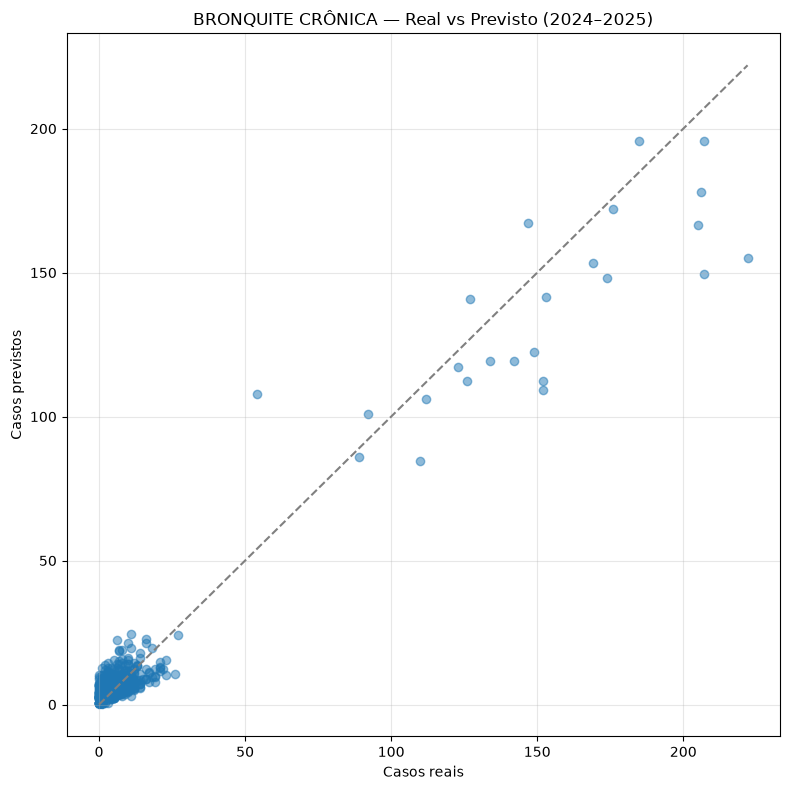

In [24]:
mu.plot_real_vs_predicted(
    resultado["test_final"]["cases"],
    resultado["final_pred"],
    DISEASE
)

### B) Backtest temporal por município

Porto Alegre tem o maior volume de casos no teste (3.613) e aparece em treino e teste — usado como principal referência. Complementado por Soledade e Bagé (2º e 3º em casos no teste).

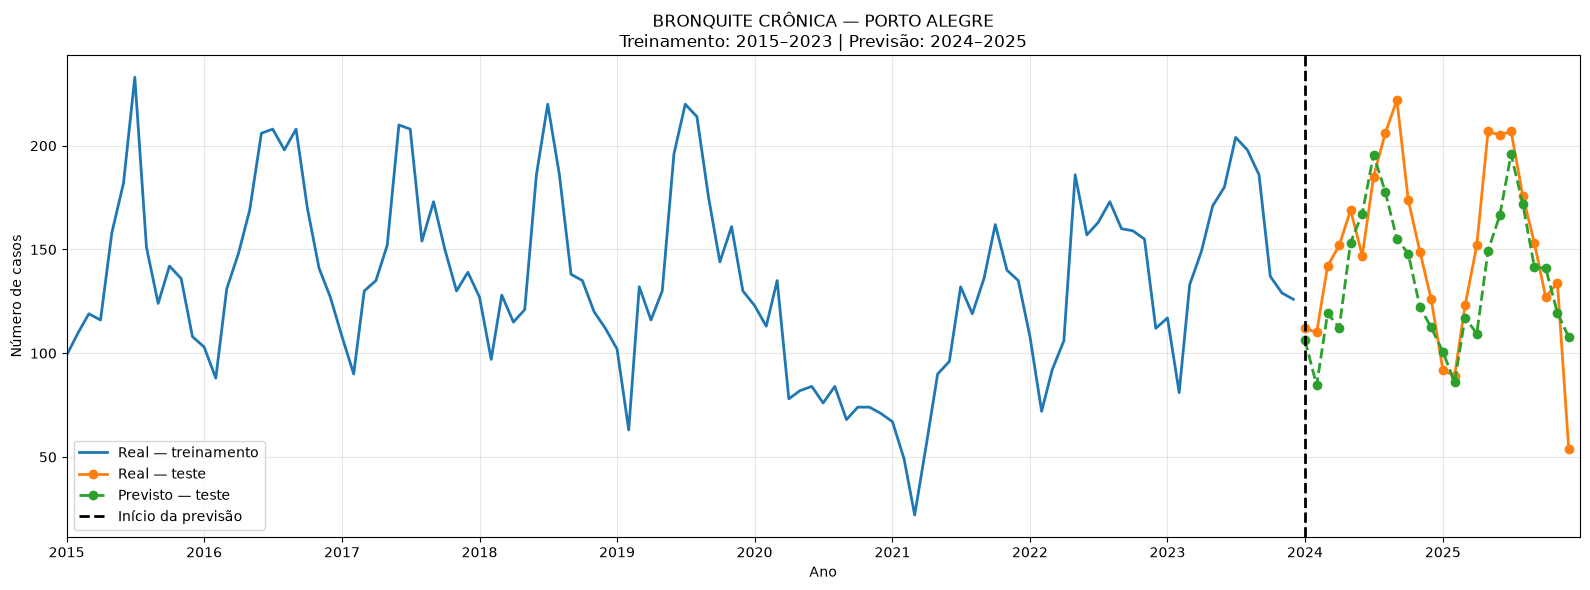

In [25]:
historical_df = train_disease0.copy()

forecast_df = resultado["test_final"].copy()
forecast_df["prediction"] = resultado["final_pred"]

plot_backtest = mu.make_backtest_plotter(DISEASE, historical_df, forecast_df)

plot_backtest("PORTO ALEGRE")

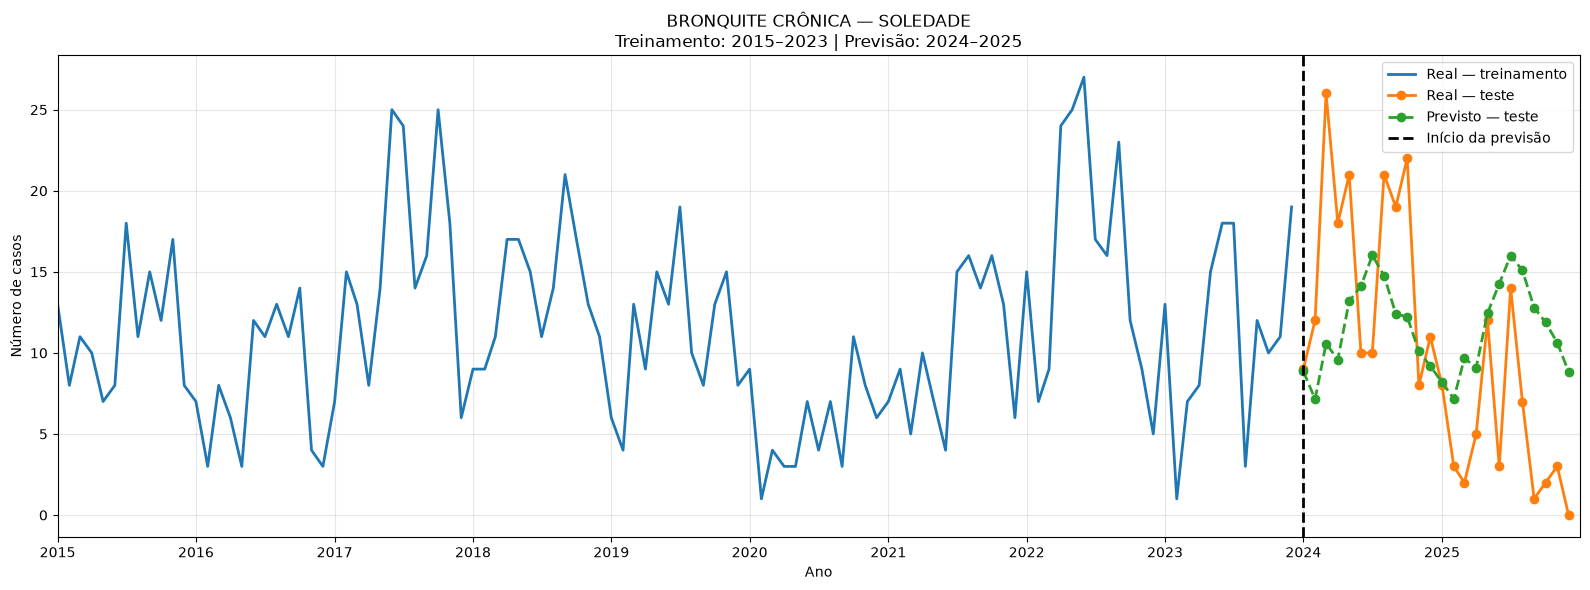

In [26]:
plot_backtest("SOLEDADE")

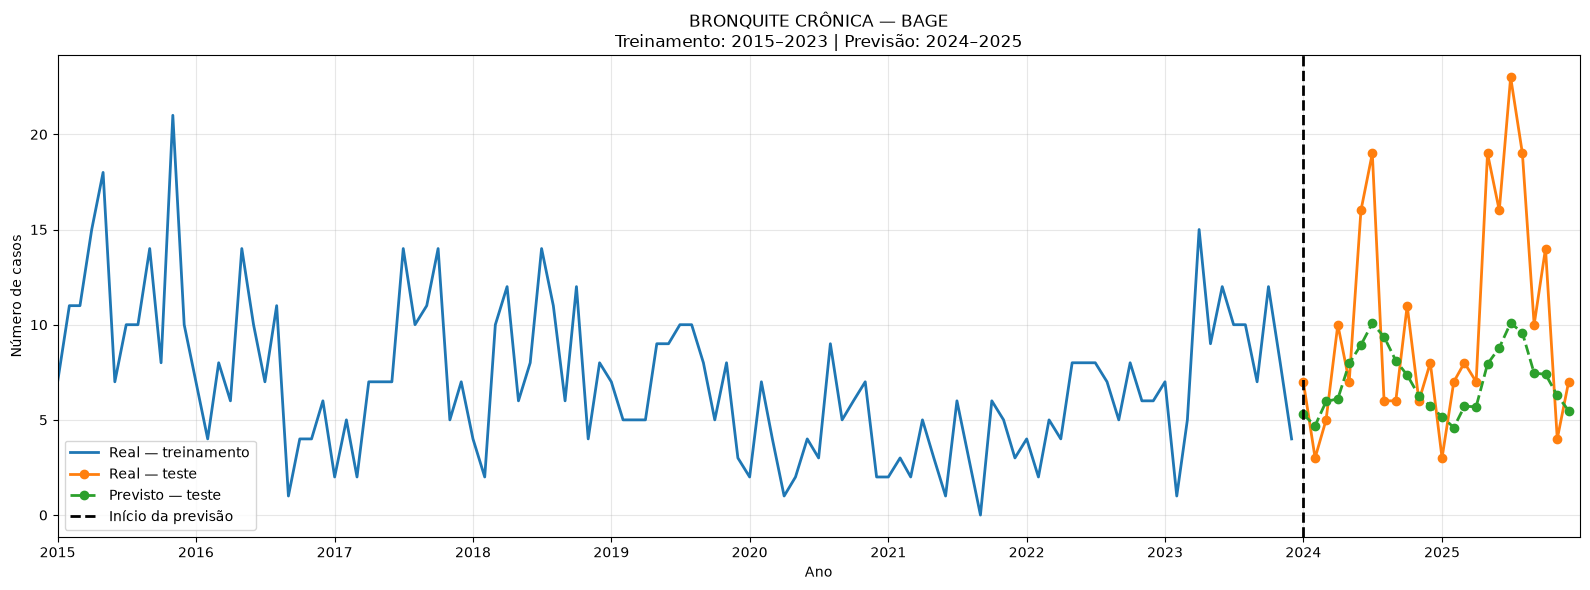

In [27]:
plot_backtest("BAGE")

Nos três municípios, o modelo acompanha razoavelmente o nível médio e a sazonalidade dos casos observados, com maior dificuldade em capturar picos pontuais — esperado, já que a variável climática tem contribuição modesta e não foi otimizada para eventos extremos.

### C) Baseline vs modelo climático (Porto Alegre, 2024-2025)

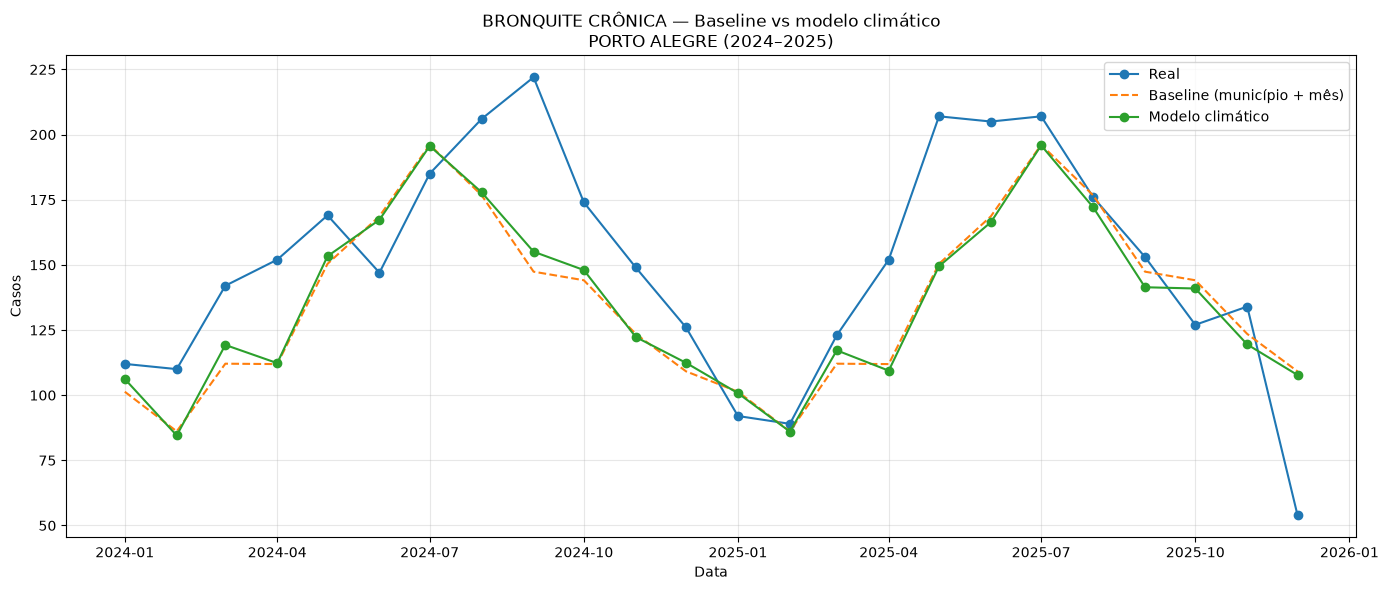

In [28]:
plot_df = resultado["test_final"][
    resultado["test_final"]["municipality"] == "PORTO ALEGRE"
].copy()

plot_df["baseline_pred"] = resultado["base_model"].predict(plot_df)
plot_df["climate_pred"] = resultado["final_model"].predict(plot_df)

mu.plot_baseline_vs_climate(DISEASE, "PORTO ALEGRE", plot_df)

### D) Tabela de métricas por município

**Atenção**: WAPE e MAE normalizado não devem ser interpretados como "acurácia", especialmente em municípios com poucos casos (ou meses com zero casos), nos quais pequenas diferenças absolutas geram erros percentuais desproporcionais.

In [29]:
evaluation_df = resultado["test_final"][
    ["municipality", "reference_date", "cases"]
].copy()

evaluation_df["prediction"] = resultado["final_pred"]

municipality_table = mu.municipality_metrics_table(evaluation_df)

display(municipality_table)

,municipality,n,mean_cases,mae,rmse,wape_pct,r2
0,CAMBARA DO SUL,24,0.750000,0.640865,0.770571,85.448648,0.017192
1,TRAMANDAI,20,3.450000,1.471231,1.698766,42.644370,0.249953
2,TORRES,3,0.333333,1.754967,1.777896,526.490183,-13.224121
3,CAMPO BOM,21,4.047619,1.522730,1.938201,37.620396,-0.178287
4,SANTA ROSA,12,3.250000,1.643510,1.969902,50.569528,-0.773949
5,CANELA,21,3.142857,1.868971,2.213313,59.467250,0.117504
6,PALMEIRA DAS MISSOES,22,4.363636,1.828471,2.221612,41.902451,-0.033223
7,SANTIAGO,24,5.166667,1.801731,2.417938,34.872210,0.226209
8,URUGUAIANA,10,4.700000,2.284345,2.721884,48.603077,0.314648
9,TEUTONIA,19,0.368421,2.655326,2.850145,720.731417,-13.810715


## 13. Municípios excluídos do backtest

In [30]:
# Comparamos os municípios válidos do teste ANTES do filtro de "município
# não visto" (que já é aplicado internamente por `fit_final_models`) contra
# os municípios do treino final -- comparar `train_final`/`test_final` (ambos
# já filtrados) resultaria sempre em um conjunto vazio por construção, o que
# não verificaria de fato se alguma exclusão ocorreu.
test_disease_dropna = test_disease0.dropna(
    subset=["cases", "municipality", "month"] + features_selecionadas
)

excluded_municipalities = mu.unseen_municipalities(
    resultado["train_final"],
    test_disease_dropna
)

print("Municípios excluídos do backtest:", excluded_municipalities)


Municípios excluídos do backtest: set()


Não há municípios excluídos: todos os 27 municípios com registros de bronquite crônica no período de teste também aparecem no treino válido para `wind_gust_max_ms`, portanto nenhuma categoria de município é "inventada" no backtest.

## 14. Interpretação final

Para bronquite crônica, o modelo Binomial Negativo com efeitos de município e mês já explica a maior parte da variação dos casos (R²≈0,94 no teste), refletindo diferenças estruturais entre municípios e sazonalidade.

**Seleção de features.** A correção do vazamento (validação 2023, nunca 2024-2025) elegeu `wind_gust_max_ms` como melhor variável (MAE≈4,26%, RMSE≈9,44%, p≈0,014), substituindo `wind_gust_max_ms_lag2` da 1ª versão. Várias variáveis com forte significância no treino (umidade relativa, precipitação, defasagens de ponto de orvalho) pioraram fora da amostra — significância estatística não é capacidade preditiva.

**Backtest oficial (2024-2025).** O modelo final convergiu (alpha≈0,240) e melhorou ≈0,97% de MAE e ≈2,67% de RMSE sobre o modelo-base — ganho real, porém modesto, na mesma ordem de grandeza da 1ª versão.

**Limitações.** A rajada de vento é usada como proxy de mudança de padrão climático (ex.: frentes frias), não como mecanismo causal identificado — não se pode afirmar que rajadas "causam" bronquite crônica. O ganho modesto sugere que fatores não capturados (poluição, tabagismo, comorbidades, padrões de busca por atendimento) explicam parte relevante da variação residual. Resultados específicos ao RS, 2015-2025; não extrapolar sem nova validação.

## 15. Persistência de artefatos

In [31]:
metrics = {
    "disease": DISEASE,
    "disease_key": "bronquite_cronica",
    "formula": resultado["formula"],
    "alpha": resultado["alpha"],
    "converged": resultado["final_converged"],
    "base_converged": resultado["base_converged"],
    "aic": final_model.aic,
    "log_likelihood": final_model.llf,
    "coefficients": final_model.params.to_dict(),
    "pvalues": final_model.pvalues.to_dict(),
    "baseline_mae": resultado["base_metrics"]["mae"],
    "baseline_rmse": resultado["base_metrics"]["rmse"],
    "model_mae": resultado["final_metrics"]["mae"],
    "model_rmse": resultado["final_metrics"]["rmse"],
    "mae_improvement_pct": resultado["mae_improvement_pct"],
    "rmse_improvement_pct": resultado["rmse_improvement_pct"],
    "r2_test": resultado["final_metrics"]["r2"],
    "wape_pct": resultado["final_metrics"]["wape_pct"],
    "train_n": len(resultado["train_final"]),
    "test_n": len(resultado["test_final"]),
    "selected_features": features_selecionadas,
    "feature_selection_method": (
        "mu.feature_selection_split: treino 2015-2022 / validacao 2023, usado "
        "exclusivamente para escolher variaveis climaticas e lags (evaluate_candidate_features). "
        "O modelo final continua treinado em 2015-2023 e avaliado em 2024-2025 (test_disease0), "
        "sem nenhuma mudanca nesse contrato."
    ),
    "climate_variable_tests": climate_results.to_dict(orient="records"),
    "lag_variable_tests": lag_results.to_dict(orient="records"),
    "excluded_municipalities": list(excluded_municipalities),
    "feature_selection_rationale": (
        "Apenas wind_gust_max_ms (sem defasagem) foi selecionada, com base em validacao "
        "2023 (treino 2015-2022 / validacao 2023, via mu.feature_selection_split), nunca no "
        "conjunto de teste 2024-2025: melhor e mais consistente melhora fora da amostra entre "
        "9 variaveis climaticas e 16 candidatos de lag (MAE ~4.26%, RMSE ~9.44%), significativa "
        "a 5% (p ~ 0.014 na validacao; p ~ 0.036 no modelo final treinado em 2015-2023). Variaveis "
        "com forte significancia no treino mas que pioraram o desempenho fora da amostra "
        "(umidade relativa, precipitacao e suas defasagens, defasagens de ponto de orvalho) foram "
        "descartadas. Ao combinar com precipitation_max_observation_mm_lag3 (teste de "
        "multicolinearidade), essa segunda variavel perde significancia (p ~ 0.114) e a amostra "
        "valida diminui, sem ganho claramente atribuivel; por isso mantemos o modelo parcimonioso "
        "com uma unica feature climatica. No backtest oficial (2024-2025), o ganho e modesto "
        "(~1% MAE, ~2.7% RMSE), na mesma ordem de grandeza observada antes da correcao do "
        "vazamento de selecao (quando wind_gust_max_ms_lag2 havia sido escolhida usando o proprio "
        "conjunto de teste). Isso confirma que municipio + sazonalidade ja explicam a maior parte "
        "da variacao dos casos de bronquite cronica, e que o vazamento original nao havia inflado "
        "de forma relevante o ganho reportado, apenas a variavel escolhida."
    )
}

predictions_df = resultado["test_final"][
    ["municipality", "reference_date", "cases"]
].copy()
predictions_df["prediction"] = resultado["final_pred"]

mu.save_disease_artifacts("bronquite_cronica", metrics, predictions_df)

print("Artefatos salvos em:", mu.ARTIFACTS_DIR)
print(sorted(p.name for p in mu.ARTIFACTS_DIR.glob("bronquite_cronica_*")))

Artefatos salvos em: C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\artifacts\modeling
['bronquite_cronica_metrics.json', 'bronquite_cronica_predictions.parquet']
